# Load Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

# Style
sns.set_style("whitegrid")

# Load Dataset

In [3]:
df = pd.read_csv("D:\Computing Stastic 2\python\Decodelab\cleaned_dataset_final.csv")

# First 5 rows
df.head()

<>:1: SyntaxWarning: invalid escape sequence '\C'
<>:1: SyntaxWarning: invalid escape sequence '\C'
C:\Users\Cheema Don\AppData\Local\Temp\ipykernel_14784\367377327.py:1: SyntaxWarning: invalid escape sequence '\C'
  df = pd.read_csv("D:\Computing Stastic 2\python\Decodelab\cleaned_dataset_final.csv")


,OrderID,Date,CustomerID,Product,Quantity,UnitPrice,ShippingAddress,PaymentMethod,OrderStatus,TrackingNumber,ItemsInCart,CouponCode,ReferralSource,TotalPrice
0,ORD200000,2023-01-04,C72649,Monitor,5,570.62,928 Main St,Debit Card,Shipped,TRK37947903,7,SAVE10,Instagram,2853.10
1,ORD200001,2024-08-23,C75739,Phone,2,151.35,823 Main St,Online,Shipped,TRK91186779,3,SAVE10,Referral,302.70
2,ORD200002,2024-02-27,C81728,Tablet,5,550.68,512 Main St,Credit Card,Cancelled,TRK42903982,8,FREESHIP,Email,2753.40
3,ORD200003,2023-10-15,C33540,Chair,1,273.19,275 Main St,Debit Card,Returned,TRK62788070,5,SAVE10,Facebook,273.19
4,ORD200004,2025-05-08,C81840,Printer,4,626.01,668 Main St,Online,Delivered,TRK29241424,8,SAVE10,Email,2504.04


# Dataset Information

In [4]:
print("Shape of Dataset:")
print(df.shape)

print("\nColumns:")
print(df.columns)

print("\nInformation:")
df.info()

Shape of Dataset:
(1200, 14)

Columns:
Index(['OrderID', 'Date', 'CustomerID', 'Product', 'Quantity', 'UnitPrice',
       'ShippingAddress', 'PaymentMethod', 'OrderStatus', 'TrackingNumber',
       'ItemsInCart', 'CouponCode', 'ReferralSource', 'TotalPrice'],
      dtype='str')

Information:
<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          1200 non-null   str    
 1   Date             1200 non-null   str    
 2   CustomerID       1200 non-null   str    
 3   Product          1200 non-null   str    
 4   Quantity         1200 non-null   int64  
 5   UnitPrice        1200 non-null   float64
 6   ShippingAddress  1200 non-null   str    
 7   PaymentMethod    1200 non-null   str    
 8   OrderStatus      1200 non-null   str    
 9   TrackingNumber   1200 non-null   str    
 10  ItemsInCart      1200 non-null   int64  
 11  CouponCo

# Check Missing Values


In [5]:
print("Missing Values")

df.isnull().sum()

Missing Values


OrderID            0
Date               0
CustomerID         0
Product            0
Quantity           0
UnitPrice          0
ShippingAddress    0
PaymentMethod      0
OrderStatus        0
TrackingNumber     0
ItemsInCart        0
CouponCode         0
ReferralSource     0
TotalPrice         0
dtype: int64

# Check Duplicate Records

In [6]:
print("Duplicate Rows:")

print(df.duplicated().sum())

Duplicate Rows:
0


# Statistical Summary

In [7]:
df.describe()

,Quantity,UnitPrice,ItemsInCart,TotalPrice
count,1200.000000,1200.000000,1200.000000,1200.000000
mean,2.945833,356.412750,5.485000,1053.968300
std,1.407557,197.177146,2.281983,819.856558
min,1.000000,11.390000,1.000000,11.390000
25%,2.000000,186.062500,4.000000,410.520000
50%,3.000000,364.210000,5.000000,823.615000
75%,4.000000,521.570000,7.000000,1578.475000
max,5.000000,699.930000,10.000000,3456.400000


# Mean, Median and Count

In [8]:
numeric_columns = df.select_dtypes(include=['int64','float64']).columns

summary = pd.DataFrame({
    "Mean": df[numeric_columns].mean(),
    "Median": df[numeric_columns].median(),
    "Count": df[numeric_columns].count()
})

summary

,Mean,Median,Count
Quantity,2.945833,3.000,1200
UnitPrice,356.412750,364.210,1200
ItemsInCart,5.485000,5.000,1200
TotalPrice,1053.968300,823.615,1200


# Correlation Matrix

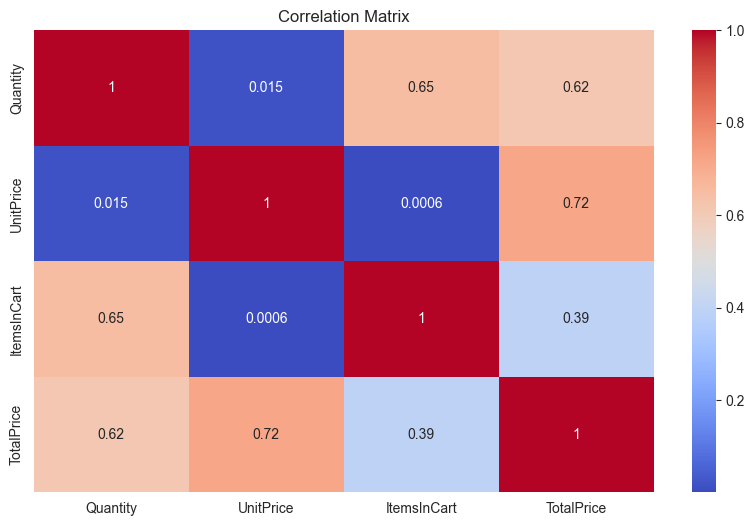

In [9]:
plt.figure(figsize=(10,6))

sns.heatmap(df[numeric_columns].corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

# Distribution of Numeric Columns

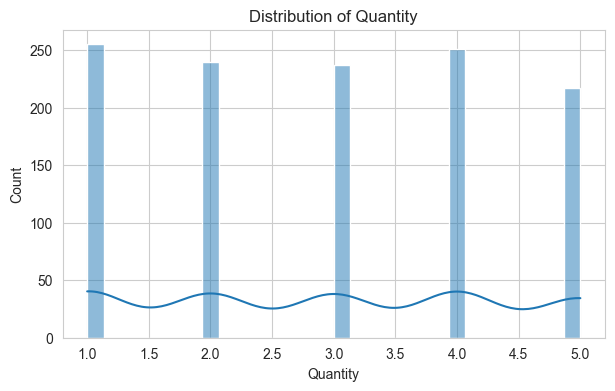

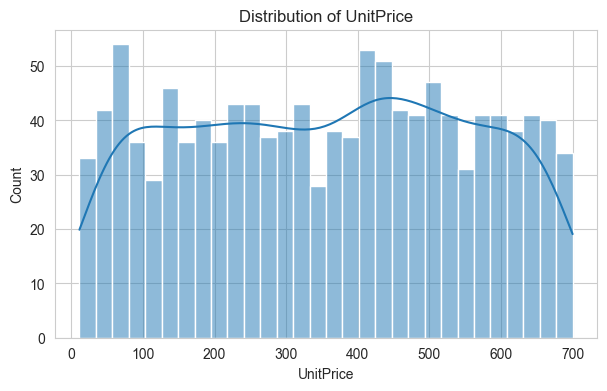

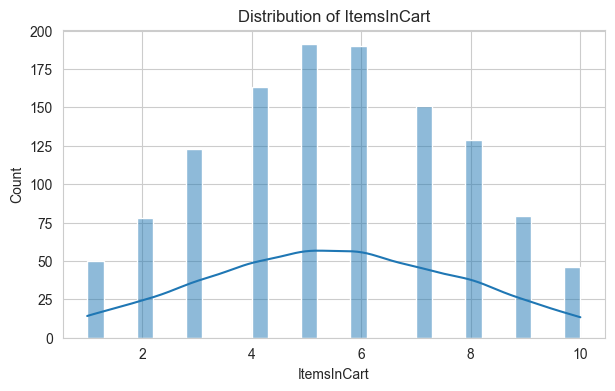

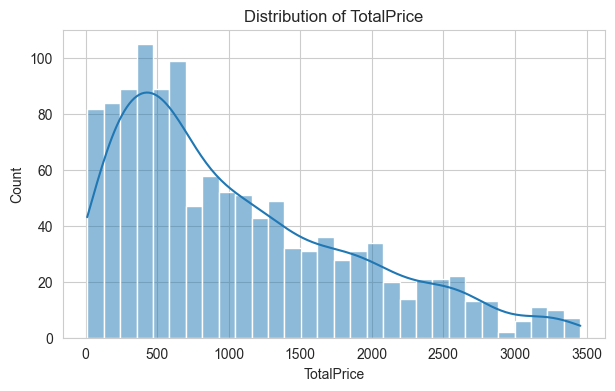

In [10]:
for column in numeric_columns:
    
    plt.figure(figsize=(7,4))
    
    sns.histplot(df[column], bins=30, kde=True)
    
    plt.title(f"Distribution of {column}")
    
    plt.show()

# Boxplots (Outlier Detection)

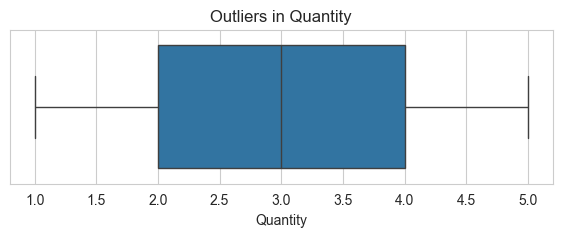

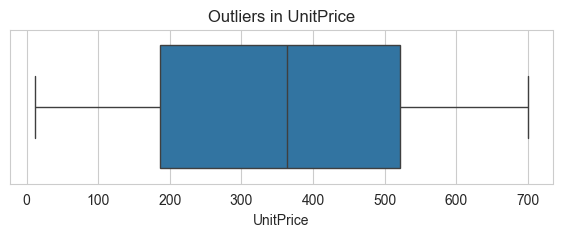

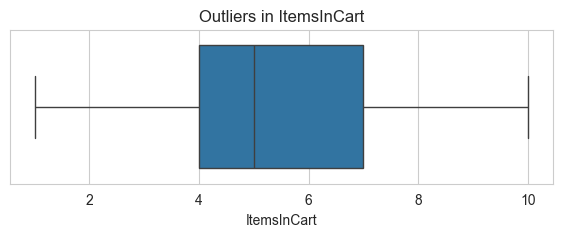

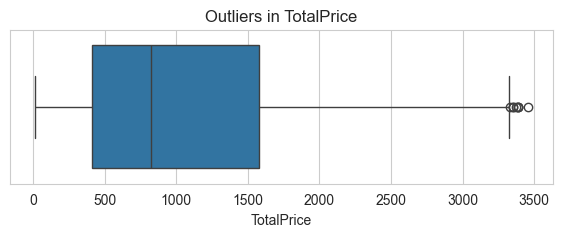

In [11]:
for column in numeric_columns:

    plt.figure(figsize=(7,2))

    sns.boxplot(x=df[column])

    plt.title(f"Outliers in {column}")

    plt.show()

# Product Frequency

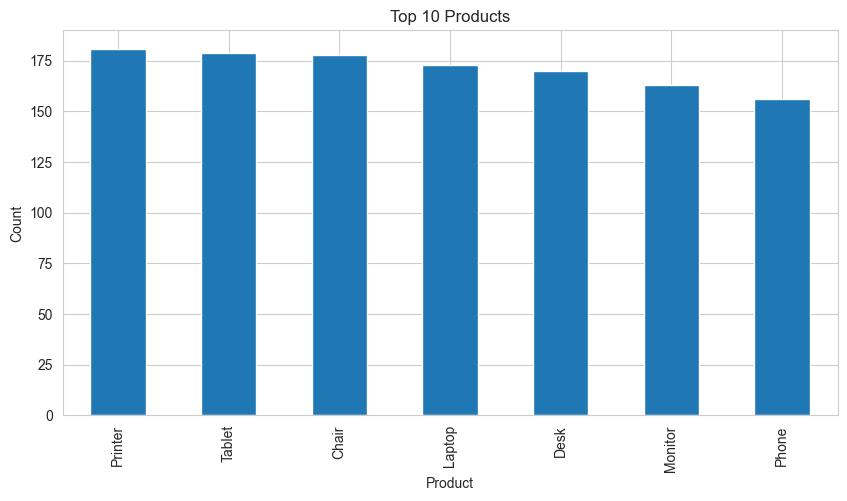

In [12]:
if 'Product' in df.columns:
    
    plt.figure(figsize=(10,5))

    df['Product'].value_counts().head(10).plot(kind='bar')

    plt.title("Top 10 Products")

    plt.xlabel("Product")

    plt.ylabel("Count")

    plt.show()

# Order Status

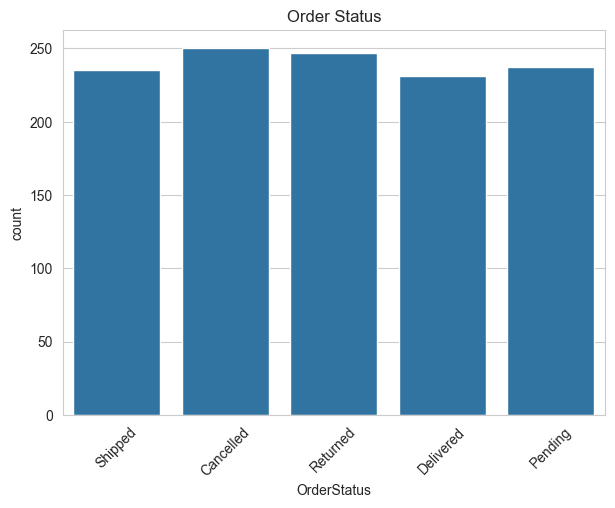

In [13]:
if 'OrderStatus' in df.columns:

    plt.figure(figsize=(7,5))

    sns.countplot(data=df,
                  x='OrderStatus')

    plt.xticks(rotation=45)

    plt.title("Order Status")

    plt.show()

# Payment Method

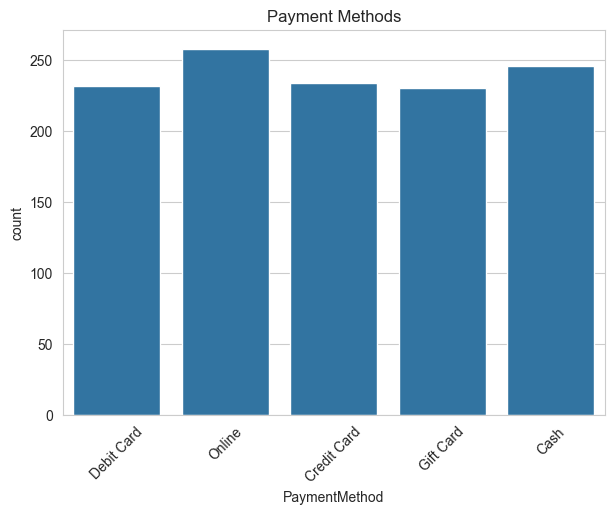

In [14]:
if 'PaymentMethod' in df.columns:

    plt.figure(figsize=(7,5))

    sns.countplot(data=df,
                  x='PaymentMethod')

    plt.xticks(rotation=45)

    plt.title("Payment Methods")

    plt.show()

# Total Sales by Product

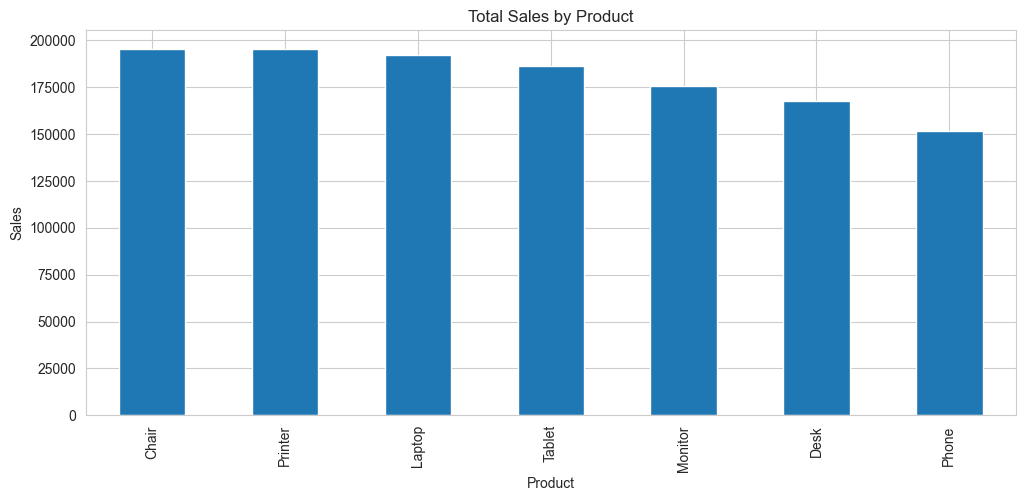

In [15]:
if 'Product' in df.columns and 'TotalPrice' in df.columns:

    sales = df.groupby('Product')['TotalPrice'].sum().sort_values(ascending=False)

    plt.figure(figsize=(12,5))

    sales.plot(kind='bar')

    plt.title("Total Sales by Product")

    plt.ylabel("Sales")

    plt.show()

# Monthly Sales Trend

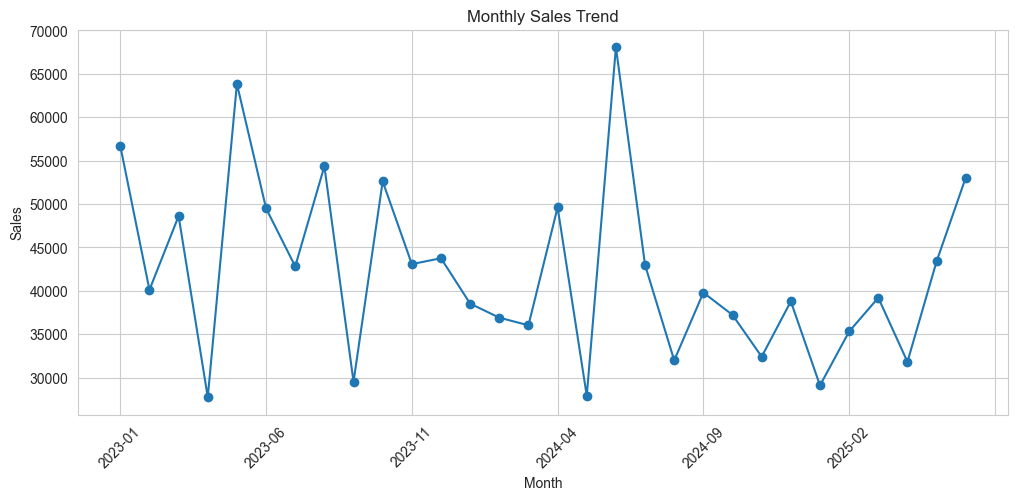

In [16]:
if 'Date' in df.columns:

    df['Date'] = pd.to_datetime(df['Date'])

    monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['TotalPrice'].sum()

    monthly_sales.index = monthly_sales.index.astype(str)

    plt.figure(figsize=(12,5))

    monthly_sales.plot(marker='o')

    plt.title("Monthly Sales Trend")

    plt.xlabel("Month")

    plt.ylabel("Sales")

    plt.xticks(rotation=45)

    plt.show()

# Quantity vs Total Price

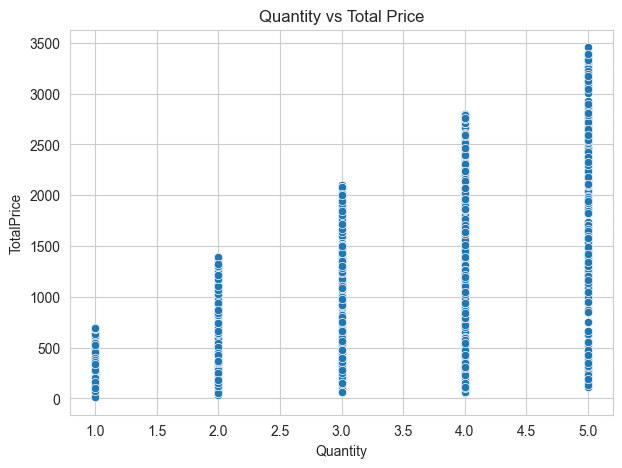

In [18]:
if 'Quantity' in df.columns and 'TotalPrice' in df.columns:

    plt.figure(figsize=(7,5))

    sns.scatterplot(data=df,
                    x='Quantity',
                    y='TotalPrice')

    plt.title("Quantity vs Total Price")

    plt.show()

# Top Referral Sources

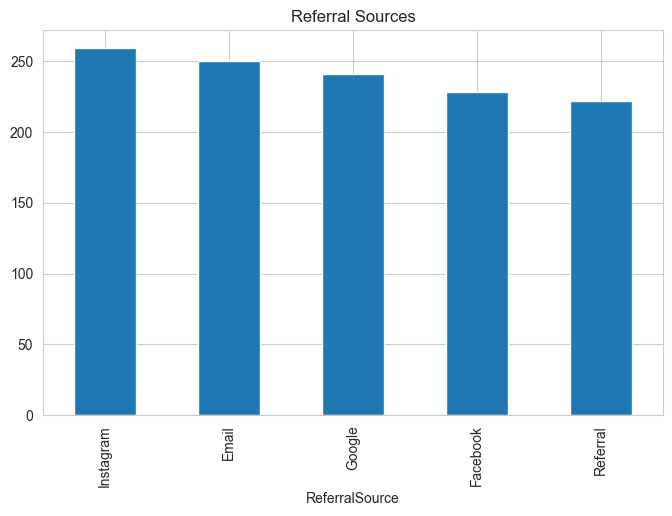

In [19]:
if 'ReferralSource' in df.columns:

    plt.figure(figsize=(8,5))

    df['ReferralSource'].value_counts().plot(kind='bar')

    plt.title("Referral Sources")

    plt.show()

# Shipping Cities

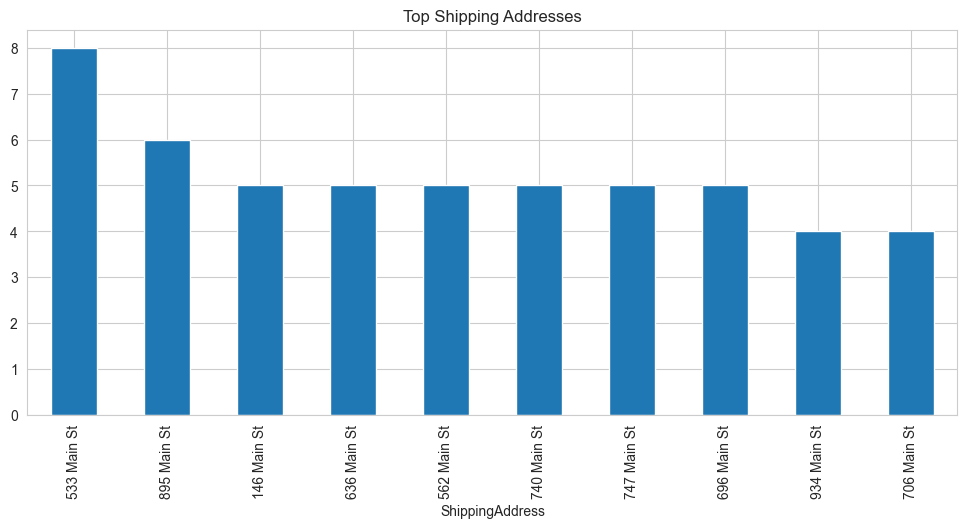

In [20]:
if 'ShippingAddress' in df.columns:

    top_city = df['ShippingAddress'].value_counts().head(10)

    plt.figure(figsize=(12,5))

    top_city.plot(kind='bar')

    plt.title("Top Shipping Addresses")

    plt.show()

# Pair Plot

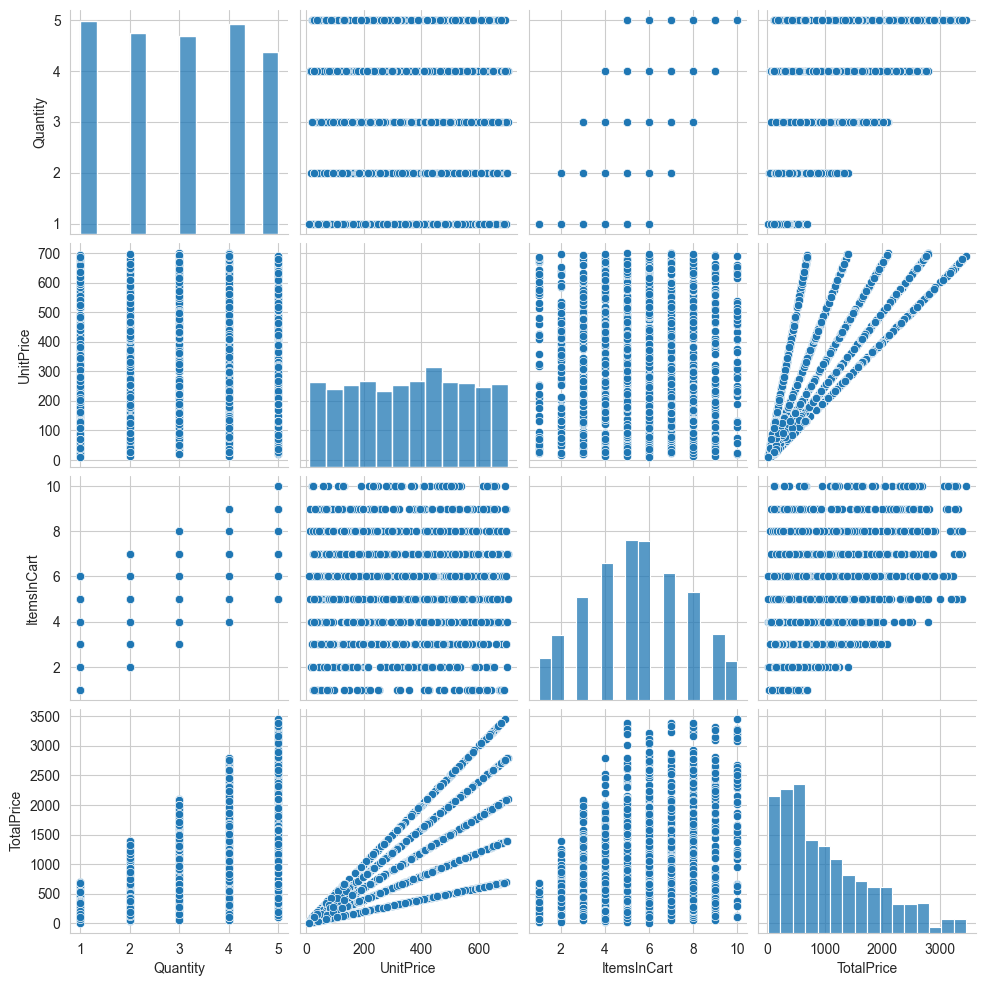

In [21]:
sns.pairplot(df[numeric_columns])

plt.show()

# Final Observations

In [22]:
print("EDA Completed Successfully")

print("\nKey Findings:")

print("1. Dataset structure analyzed.")
print("2. Missing values checked.")
print("3. Duplicate records identified.")
print("4. Summary statistics generated.")
print("5. Correlation between numerical variables analyzed.")
print("6. Outliers detected using boxplots.")
print("7. Product sales analyzed.")
print("8. Monthly sales trend visualized.")
print("9. Payment methods analyzed.")
print("10. Order status distribution visualized.")

EDA Completed Successfully

Key Findings:
1. Dataset structure analyzed.
2. Missing values checked.
3. Duplicate records identified.
4. Summary statistics generated.
5. Correlation between numerical variables analyzed.
6. Outliers detected using boxplots.
7. Product sales analyzed.
8. Monthly sales trend visualized.
9. Payment methods analyzed.
10. Order status distribution visualized.
